In [17]:
def plot_comparison_2(data_dict, input_params):
    """Four subplot version with consistent y-axis limits"""
    # Unpack input parameters
    norm_type, index, numsteps, epsilon, alpha = input_params
    
    # Extract the data
    input = data_dict['a_values']['a'].squeeze()
    input_with_solver = data_dict['a_values']['a_with'].squeeze()
    input_without_solver = data_dict['a_values']['a_without'].squeeze()
    input_approximate = data_dict['a_values']['a_approximate'].squeeze()
    
    FNO = data_dict['G_values']['G(a)'].squeeze()
    FNO_with_solver = data_dict['G_values']['G(a_with)'].squeeze()
    FNO_without_solver = data_dict['G_values']['G(a_without)'].squeeze()
    FNO_approximate = data_dict['G_values']['G(a_approximate)'].squeeze()
    
    PDE = data_dict['g_values']['g(a)']
    PDE_with_solver = data_dict['g_values']['g(a_with)']
    PDE_without_solver = data_dict['g_values']['g(a_without)']
    PDE_approximate = data_dict['g_values']['g(a_approximate)']
    
    # Calculate global y-axis limits for consistent scaling
    all_values = np.concatenate([
        input, input_with_solver, input_without_solver, input_approximate,
        FNO, FNO_with_solver, FNO_without_solver, FNO_approximate,
        PDE, PDE_with_solver, PDE_without_solver, PDE_approximate
    ])
    y_min = min(all_values) * 0.95
    y_max = max(all_values) * 1.05
    
    # Create figure with four subplots in one row
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(24, 6))
    
    # Plot 1: Original values
    ax1.plot(input, 'b-', label='Original input', alpha=0.7)
    ax1.plot(FNO, 'g-', label='FNO(Original input)', alpha=0.7)
    ax1.plot(PDE, 'r-', label='PDE(Original input)', alpha=0.7)
    ax1.set_title('Original Values')
    ax1.set_xlabel('Spatial/Temporal Index')
    ax1.set_ylabel('Value')
    ax1.set_ylim(y_min, y_max)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: With solver perturbation
    ax2.plot(input_with_solver, 'b-', label='Input + Perturbation with PDE solver gradient', alpha=0.7)
    ax2.plot(FNO_with_solver, 'g-', label='FNO(Input + Perturbation with PDE solver gradient)', alpha=0.7)
    ax2.plot(PDE_with_solver, 'r-', label='PDE(Input + Perturbation with PDE solver gradient)', alpha=0.7)
    ax2.set_title('With PDE Solver Gradient')
    ax2.set_xlabel('Spatial/Temporal Index')
    ax2.set_ylim(y_min, y_max)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Without solver perturbation (PDE detach)
    ax3.plot(input_without_solver, 'b-', label='Input + Perturbation PDE detached', alpha=0.7)
    ax3.plot(FNO_without_solver, 'g-', label='FNO(Input + Perturbation PDE detached)', alpha=0.7)
    ax3.plot(PDE_without_solver, 'r-', label='PDE(Input + Perturbation PDE detached)', alpha=0.7)
    ax3.set_title('Without PDE Solver Gradient (PDE Detached)')
    ax3.set_xlabel('Spatial/Temporal Index')
    ax3.set_ylim(y_min, y_max)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot 4: With approximate gradient
    ax4.plot(input_approximate, 'b-', label='Input + Perturbation PDE approximate', alpha=0.7)
    ax4.plot(FNO_approximate, 'g-', label='FNO(Input + Perturbation PDE approximate)', alpha=0.7)
    ax4.plot(PDE_approximate, 'r-', label='PDE(Input + Perturbation PDE approximate)', alpha=0.7)
    ax4.set_title('Without PDE Solver Gradient (PDE Approximated)')
    ax4.set_xlabel('Spatial/Temporal Index')
    ax4.set_ylim(y_min, y_max)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    # Main title
    fig.suptitle(
        f"Comparison of Perturbation Effects\n"
        f"Norm: {norm_type.split('_')[-1]} | Sample index: {index.split('_')[-1]} | "
        f"Steps: {numsteps.split('_')[-1]} | ϵ: {epsilon.split('_')[-1]} | α: {alpha.split('_')[-1]}",
        y=1.05
    )
    plt.tight_layout()
    plt.show()

def plot_comparison_3(data_dict, input_params):
    """Three subplot version showing inputs, FNO outputs, and PDE outputs separately, each with 4 lines"""
    # Unpack input parameters
    norm_type, index, numsteps, epsilon, alpha = input_params
    
    # Extract the data
    input = data_dict['a_values']['a'].squeeze()
    input_with_solver = data_dict['a_values']['a_with'].squeeze()
    input_without_solver = data_dict['a_values']['a_without'].squeeze()
    input_approximate = data_dict['a_values']['a_approximate'].squeeze()
    
    FNO = data_dict['G_values']['G(a)'].squeeze()
    FNO_with_solver = data_dict['G_values']['G(a_with)'].squeeze()
    FNO_without_solver = data_dict['G_values']['G(a_without)'].squeeze()
    FNO_approximate = data_dict['G_values']['G(a_approximate)'].squeeze()
    
    PDE = data_dict['g_values']['g(a)']
    PDE_with_solver = data_dict['g_values']['g(a_with)']
    PDE_without_solver = data_dict['g_values']['g(a_without)']
    PDE_approximate = data_dict['g_values']['g(a_approximate)']
    
    # Calculate y-axis limits for each category
    input_limits = (
        min(min(input), min(input_with_solver), min(input_without_solver), min(input_approximate)) * 0.95,
        max(max(input), max(input_with_solver), max(input_without_solver), max(input_approximate)) * 1.05
    )
    
    FNO_limits = (
        min(min(FNO), min(FNO_with_solver), min(FNO_without_solver), min(FNO_approximate)) * 0.95,
        max(max(FNO), max(FNO_with_solver), max(FNO_without_solver), max(FNO_approximate)) * 1.05
    )
    
    PDE_limits = (
        min(min(PDE), min(PDE_with_solver), min(PDE_without_solver), min(PDE_approximate)) * 0.95,
        max(max(PDE), max(PDE_with_solver), max(PDE_without_solver), max(PDE_approximate)) * 1.05
    )
    
    # Create figure with three subplots in one row
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: Input values (now with 4 lines)
    ax1.plot(input, color='blue', linestyle='-', label='1. Original input', alpha=0.7)
    ax1.plot(input_with_solver, color='green', linestyle='-', label='2. Original input + Perturbation \n With PDE solver gradient', alpha=0.7)
    ax1.plot(input_without_solver, color='red', linestyle='-', label='3. Original input + Perturbation \n PDE detached', alpha=0.7)
    ax1.plot(input_approximate, color='orange', linestyle='-', label='4. Original input + Perturbation \n PDE approximated', alpha=0.7)
    ax1.set_title('Input Values Comparison')
    ax1.set_xlabel('Spatial/Temporal Index')
    ax1.set_ylabel('Value')
    ax1.set_ylim(input_limits[0], input_limits[1])
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: FNO outputs (now with 4 lines)
    ax2.plot(FNO, color='blue', linestyle='-', label='1. FNO(original)', alpha=0.7)
    ax2.plot(FNO_with_solver, color='green', linestyle='-', label='2. FNO(with PDE solver gradient)', alpha=0.7)
    ax2.plot(FNO_without_solver, color='red', linestyle='-', label='3. FNO(PDE detached)', alpha=0.7)
    ax2.plot(FNO_approximate, color='orange', linestyle='-', label='4. FNO(PDE approximated)', alpha=0.7)
    ax2.set_title('FNO Outputs Comparison')
    ax2.set_xlabel('Spatial/Temporal Index')
    ax2.set_ylabel('Value')
    ax2.set_ylim(FNO_limits[0], FNO_limits[1])
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: PDE outputs (now with 4 lines)
    ax3.plot(PDE, color='blue', linestyle='-', label='1. PDE(original)', alpha=0.7)
    ax3.plot(PDE_with_solver, color='green', linestyle='-', label='2. PDE(with PDE solver gradient)', alpha=0.7)
    ax3.plot(PDE_without_solver, color='red', linestyle='-', label='3. PDE(PDE detached)', alpha=0.7)
    ax3.plot(PDE_approximate, color='orange', linestyle='-', label='4. PDE(PDE approximated)', alpha=0.7)
    ax3.set_title('PDE Outputs Comparison')
    ax3.set_xlabel('Spatial/Temporal Index')
    ax3.set_ylabel('Value')
    ax3.set_ylim(PDE_limits[0], PDE_limits[1])
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Main title
    fig.suptitle(
        f"Comparison of Inputs and Outputs\n"
        f"Norm: {norm_type.split('_')[-1]} | Sample index: {index.split('_')[-1]} | "
        f"Steps: {numsteps.split('_')[-1]} | ϵ: {epsilon.split('_')[-1]} | α: {alpha.split('_')[-1]}",
        y=1.05
    )
    plt.tight_layout()
    plt.show()

In [2]:
import pickle

# Open the pickle file in binary read mode
with open('gradient_comparison_exponax_nu0.0005.pkl', 'rb') as file:
    # Load the data from the pickle file
    data = pickle.load(file)

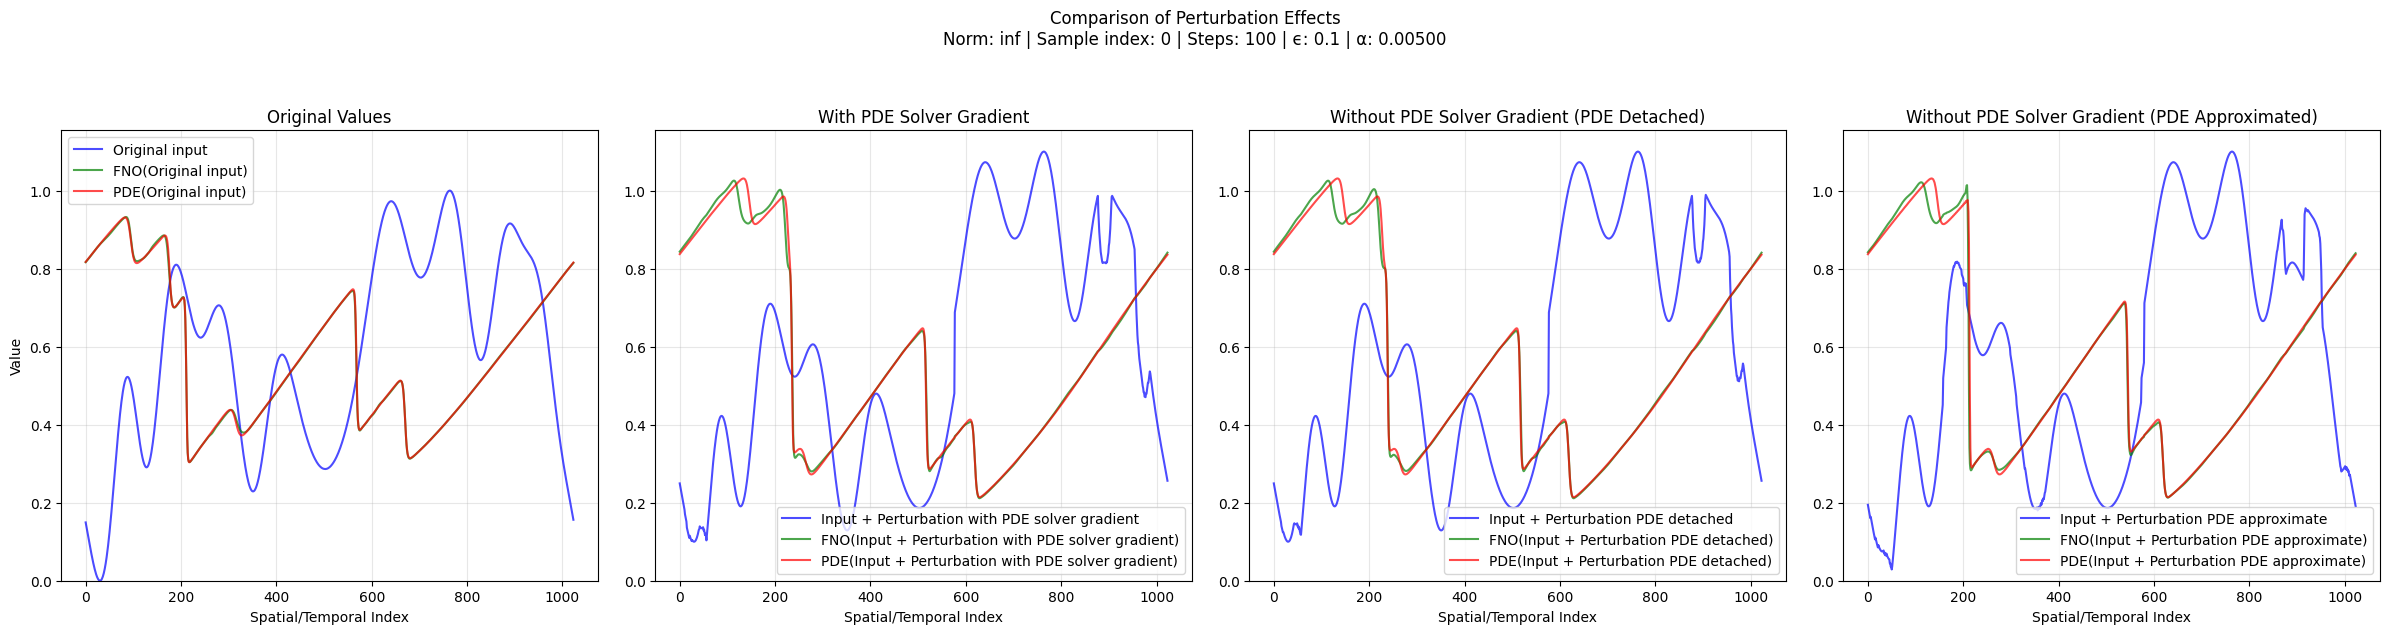

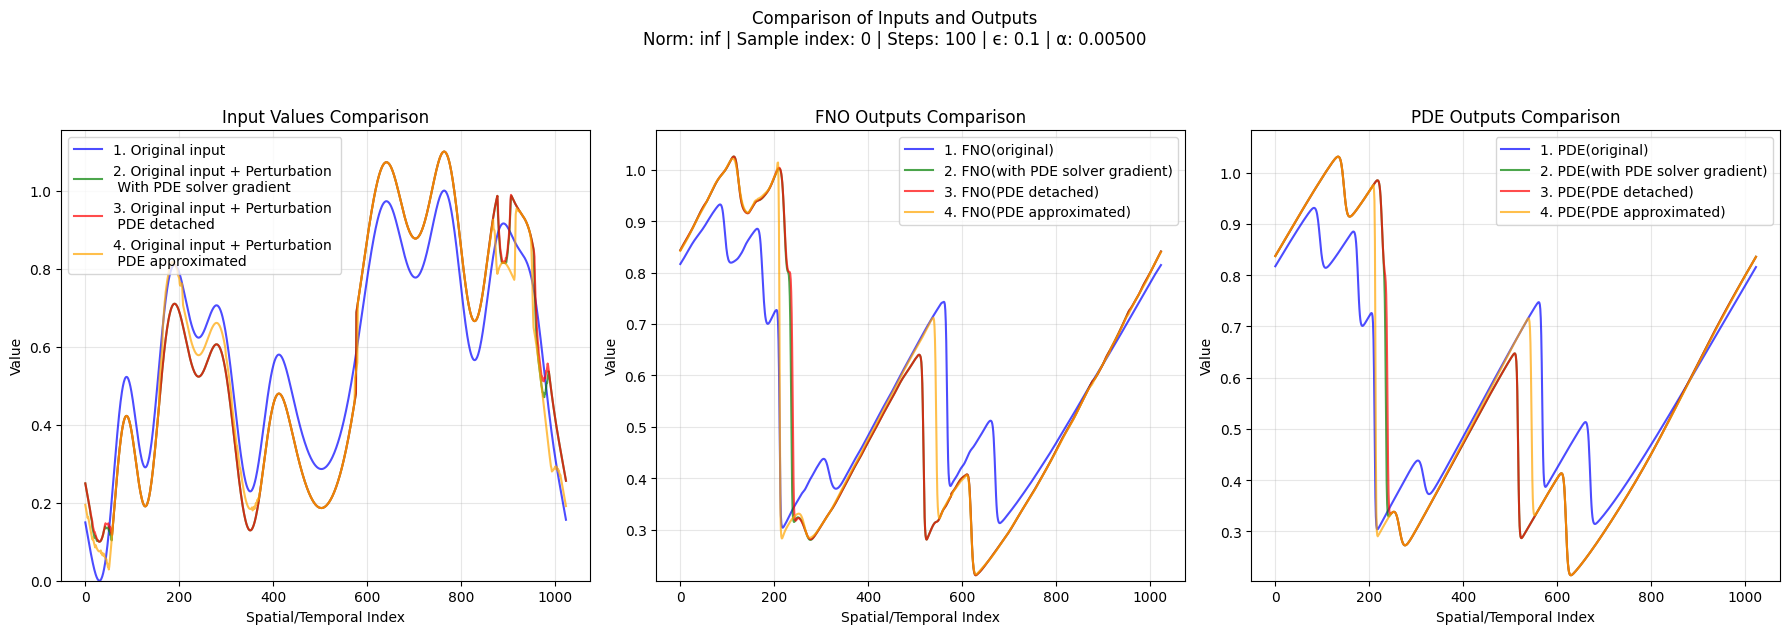

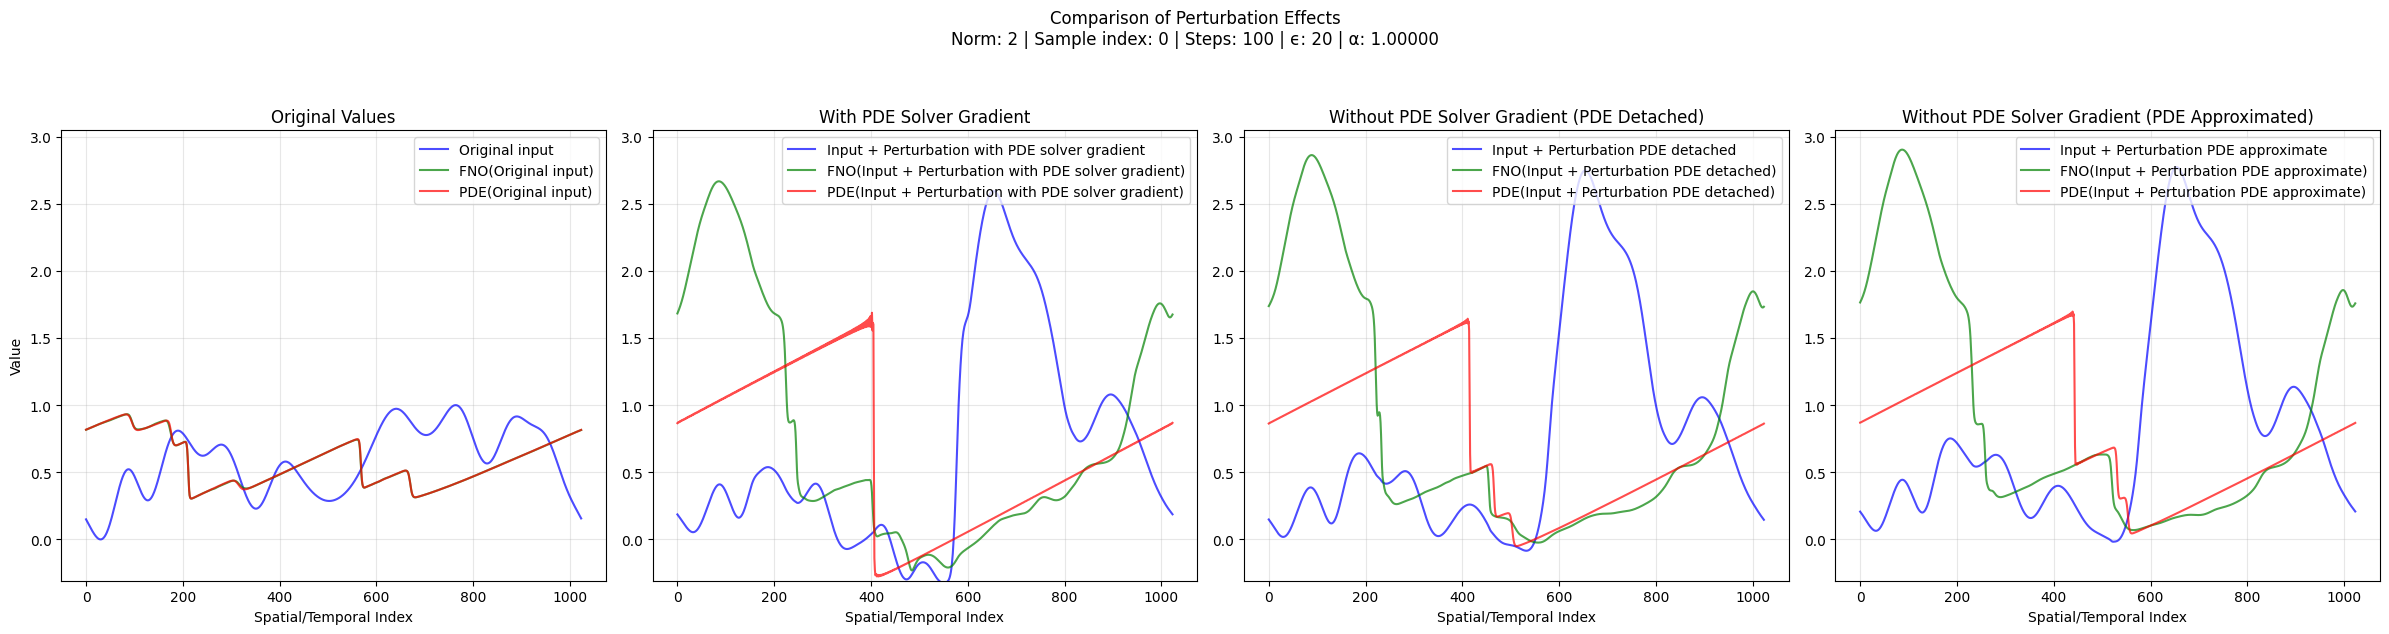

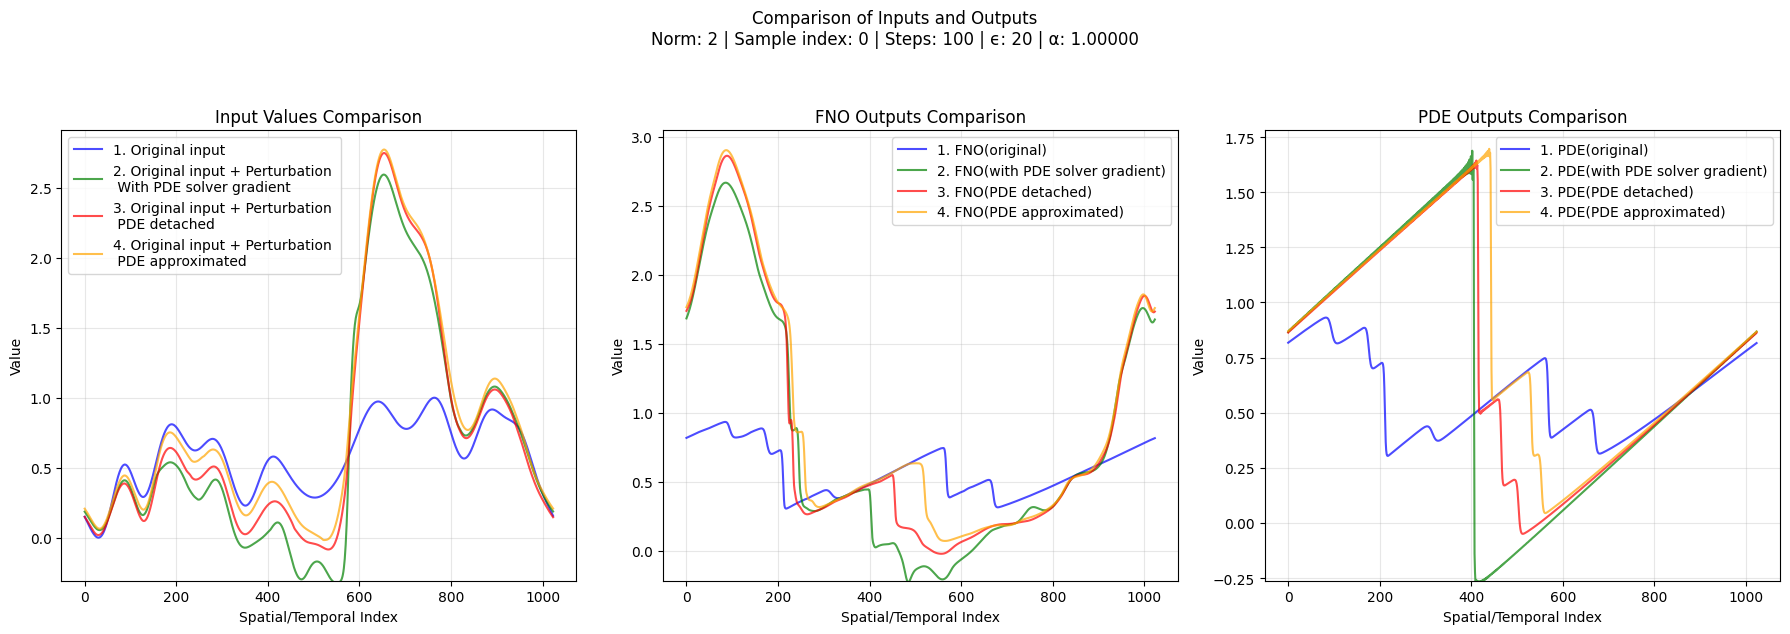

In [18]:
keys = [
        ('norm_inf', 'index_0', 'numsteps_100', 'epsilon_0.1', 'alpha_0.00500'),
        ('norm_2', 'index_0', 'numsteps_100', 'epsilon_20', 'alpha_1.00000'),
        ]
for key in keys:
    plot_comparison_2(data[key]['final_values'],key)
    plot_comparison_3(data[key]['final_values'],key)